# Word Embeddings

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
import gensim.downloader as api

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

# List of models

In [3]:
print(list(api.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


# Loading pretrained Word2Vec model

`gensim.downloader` also gives access to a pretrained **Word2Vec** model.
`word2vec-google-news-300`, trained by Google on ~100 billion words from Google News
(300-dimensional vectors, vocabulary of ~3 million words/phrases).

In [4]:
word2vec_vectors = api.load("word2vec-google-news-300")
print("Loaded Word2Vec model with", len(word2vec_vectors),
      "words, vector size:", word2vec_vectors.vector_size)

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded Word2Vec model with 3000000 words, vector size: 300


In [5]:
print("Word2Vec (Google News) - most similar to 'king':")
for similar_word, score in word2vec_vectors.most_similar("king", topn=5):
    print(f"   {similar_word:<15} {score:.4f}")

Word2Vec (Google News) - most similar to 'king':
   kings           0.7138
   queen           0.6511
   monarch         0.6413
   crown_prince    0.6204
   prince          0.6160


In [6]:
for word in ["king", "computer", "happy"]:
    print(f"\nWords most similar to '{word}' (Word2Vec):")
    for similar_word, score in word2vec_vectors.most_similar(word, topn=5):
        print(f"   {similar_word:<15} {score:.4f}")


Words most similar to 'king' (Word2Vec):
   kings           0.7138
   queen           0.6511
   monarch         0.6413
   crown_prince    0.6204
   prince          0.6160

Words most similar to 'computer' (Word2Vec):
   computers       0.7979
   laptop          0.6640
   laptop_computer 0.6549
   Computer        0.6473
   com_puter       0.6082

Words most similar to 'happy' (Word2Vec):
   glad            0.7409
   pleased         0.6632
   ecstatic        0.6627
   overjoyed       0.6599
   thrilled        0.6514


# Loading pretrained Glove Model

In [7]:
glove_vectors = api.load("glove-wiki-gigaword-100")
print("Loaded GloVe model with", len(glove_vectors), "words, vector size:", glove_vectors.vector_size)

[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded GloVe model with 400000 words, vector size: 100


In [8]:
for word in ["king", "computer", "happy"]:
    print(f"\nWords most similar to '{word}' (GloVe):")
    for similar_word, score in glove_vectors.most_similar(word, topn=5):
        print(f"   {similar_word:<15} {score:.4f}")


Words most similar to 'king' (GloVe):
   prince          0.7682
   queen           0.7508
   son             0.7021
   brother         0.6986
   monarch         0.6978

Words most similar to 'computer' (GloVe):
   computers       0.8752
   software        0.8373
   technology      0.7642
   pc              0.7366
   hardware        0.7290

Words most similar to 'happy' (GloVe):
   'm              0.8413
   feel            0.8133
   're             0.8048
   i               0.7938
   'll             0.7916


# Cosine Similarity, word2vec, glove

In [9]:
def cosine_similarity(vec_a, vec_b):

    dot = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    return dot / (norm_a * norm_b)

# Compare manual implementation with gensim's built-in similarity (GloVe) and word2vec!
pairs = [("king", "queen"), ("king", "man"), ("man", "woman"),
         ("paris", "france"), ("king", "banana")]

print(f"{'Word 1':<10}{'Word 2':<10}{'Manual':<12}{'Word2Vec':<12}{'Gensim'}")
for w1, w2 in pairs:
    manual_sim = cosine_similarity(glove_vectors[w1], glove_vectors[w2])
    word2vec_sim = word2vec_vectors.similarity(w1, w2)
    gensim_sim = glove_vectors.similarity(w1, w2)

    print(f"{w1:<10}{w2:<10}{manual_sim:<12.4f}{word2vec_sim:12.4f}{gensim_sim:.4f}")

Word 1    Word 2    Manual      Word2Vec    Gensim
king      queen     0.7508            0.65110.7508
king      man       0.5119            0.22940.5119
man       woman     0.8323            0.76640.8323
paris     france    0.7482            0.55510.7482
king      banana    0.1609            0.13650.1609


## glove vs word2vec

Since both are pretrained on large, general-purpose text corpora, we'd expect broadly
similar (but not identical) similarity scores — differences come from the training
corpus, algorithm (GloVe uses global co-occurrence statistics; Word2Vec uses local
context windows), and dimensionality (100d GloVe vs 300d Word2Vec here).

In [10]:
pairs = [("king", "queen"), ("king", "man"), ("man", "woman"),
         ("paris", "france"), ("king", "banana")]

print(f"{'Word 1':<10}{'Word 2':<10}{'GloVe':<12}{'Word2Vec'}")
for w1, w2 in pairs:
    glove_sim = glove_vectors.similarity(w1, w2)
    w2v_sim = word2vec_vectors.similarity(w1, w2)
    print(f"{w1:<10}{w2:<10}{glove_sim:<12.4f}{w2v_sim:.4f}")

#same thing as above.. can keep this or the above where we manually compute and compare too.

Word 1    Word 2    GloVe       Word2Vec
king      queen     0.7508      0.6511
king      man       0.5119      0.2294
man       woman     0.8323      0.7664
paris     france    0.7482      0.5551
king      banana    0.1609      0.1365


# analogy - glove

Word embeddings capture relational/analogical structure through vector
arithmetic. The classic example:

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

`gensim`'s `most_similar` supports this directly via `positive`/`negative` word lists.


In [11]:
def solve_analogy(model, positive, negative, topn=5):

    results = model.most_similar(positive=positive, negative=negative, topn=topn)

    return results

print("king - man + woman = ?")
for word, score in solve_analogy(glove_vectors, positive=["king", "woman"], negative=["man"]):
    print(f"   {word:<15} {score:.4f}")

king - man + woman = ?
   queen           0.7699
   monarch         0.6843
   throne          0.6756
   daughter        0.6595
   princess        0.6521


In [12]:

analogies = [
    (["paris", "germany"], ["france"], "paris - france + germany = ?"),
    (["walking", "swam"], ["swimming"], "walking - swimming + swam = ?"),
    (["bigger", "small"], ["big"], "bigger - big + small = ?"),
]

for positive, negative, description in analogies:
    print(description)
    for word, score in solve_analogy(glove_vectors, positive, negative):
        print(f"   {word:<15} {score:.4f}")
    print()


paris - france + germany = ?
   berlin          0.8846
   frankfurt       0.7986
   vienna          0.7676
   munich          0.7543
   hamburg         0.7182

walking - swimming + swam = ?
   walked          0.6780
   crawled         0.6523
   wandered        0.6384
   hopped          0.6132
   walks           0.6122

bigger - big + small = ?
   larger          0.8925
   smaller         0.8694
   large           0.7933
   tiny            0.7139
   size            0.6559



# analogy word2vec

In [13]:
print("king - man + woman = ? (Word2Vec)")
for word, score in solve_analogy(word2vec_vectors, positive=["king", "woman"], negative=["man"]):
    print(f"   {word:<15} {score:.4f}")

print()
for positive, negative, description in analogies:
    print(description, "(Word2Vec)")
    for word, score in solve_analogy(word2vec_vectors, positive, negative):
        print(f"   {word:<15} {score:.4f}")
    print()

king - man + woman = ? (Word2Vec)
   queen           0.7118
   monarch         0.6190
   princess        0.5902
   crown_prince    0.5499
   prince          0.5377

paris - france + germany = ? (Word2Vec)
   berlin          0.4841
   german          0.4657
   lindsay_lohan   0.4559
   heidi           0.4484
   switzerland     0.4448

walking - swimming + swam = ? (Word2Vec)
   walked          0.7519
   wandered        0.6134
   walk            0.6069
   strolled        0.5875
   ambled          0.5536

bigger - big + small = ? (Word2Vec)
   larger          0.7402
   smaller         0.7330
   tiny            0.5698
   tinier          0.5440
   large           0.5192



# custom analogy

In [14]:
custom_positive = ["queen", "man"]
custom_negative = ["woman"]
print(f"{custom_negative[0]} - {custom_positive[1]} ... solving: queen - woman + man = ?")
for word, score in solve_analogy(glove_vectors, positive=custom_positive, negative=custom_negative):
    print(f"   {word:<15} {score:.4f}")

woman - man ... solving: queen - woman + man = ?
   king            0.7976
   royal           0.6835
   prince          0.6819
   crown           0.6372
   princess        0.6252


# visualize -glvoe

In [15]:
words_to_plot = [
    "king", "queen", "prince", "princess", "man", "woman",
    "paris", "france", "berlin", "germany", "rome", "italy",
    "dog", "cat", "puppy", "kitten",
    "computer", "software", "keyboard", "internet",
    "happy", "sad", "angry", "joyful",
]

words_to_plot = [w for w in words_to_plot if w in glove_vectors]
vectors = np.array([glove_vectors[w] for w in words_to_plot])
print(f"Plotting {len(words_to_plot)} words, vector shape: {vectors.shape}")

Plotting 24 words, vector shape: (24, 100)


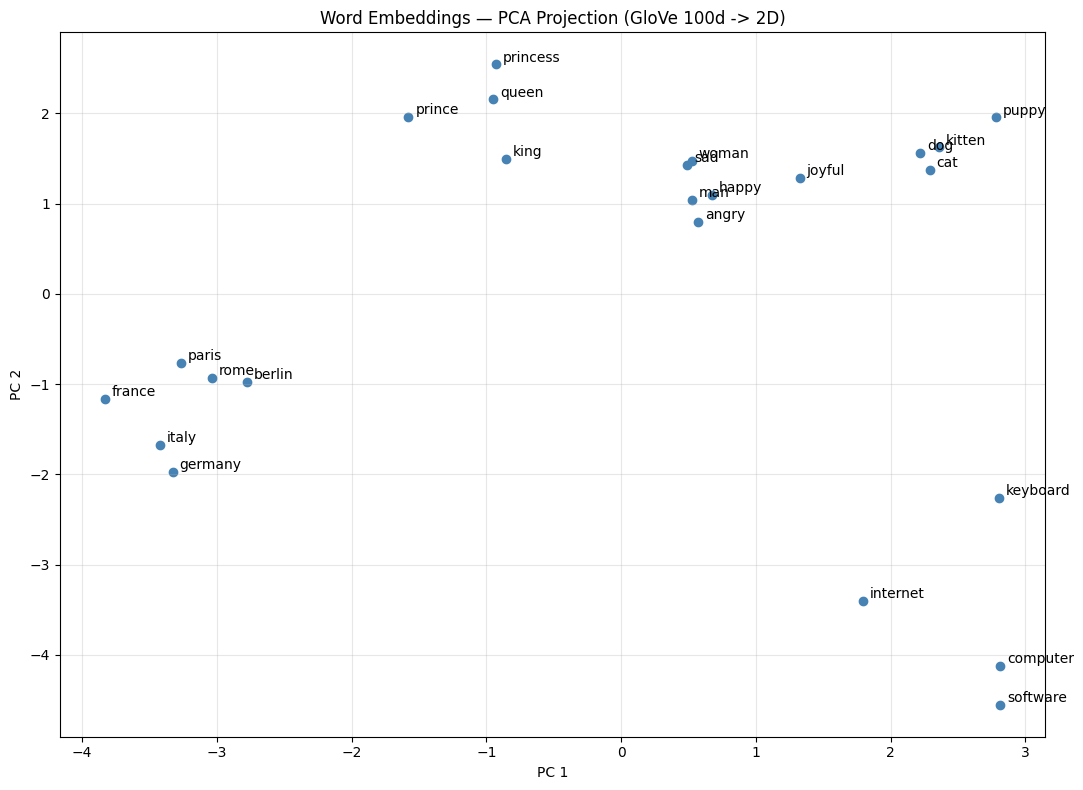

In [16]:
pca = PCA(n_components=2, random_state=42)
vectors_pca = pca.fit_transform(vectors)

plt.figure(figsize=(11, 8))
plt.scatter(vectors_pca[:, 0], vectors_pca[:, 1], c="steelblue")
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (vectors_pca[i, 0], vectors_pca[i, 1]),
                 textcoords="offset points", xytext=(5, 2), fontsize=10)
plt.title("Word Embeddings — PCA Projection (GloVe 100d -> 2D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

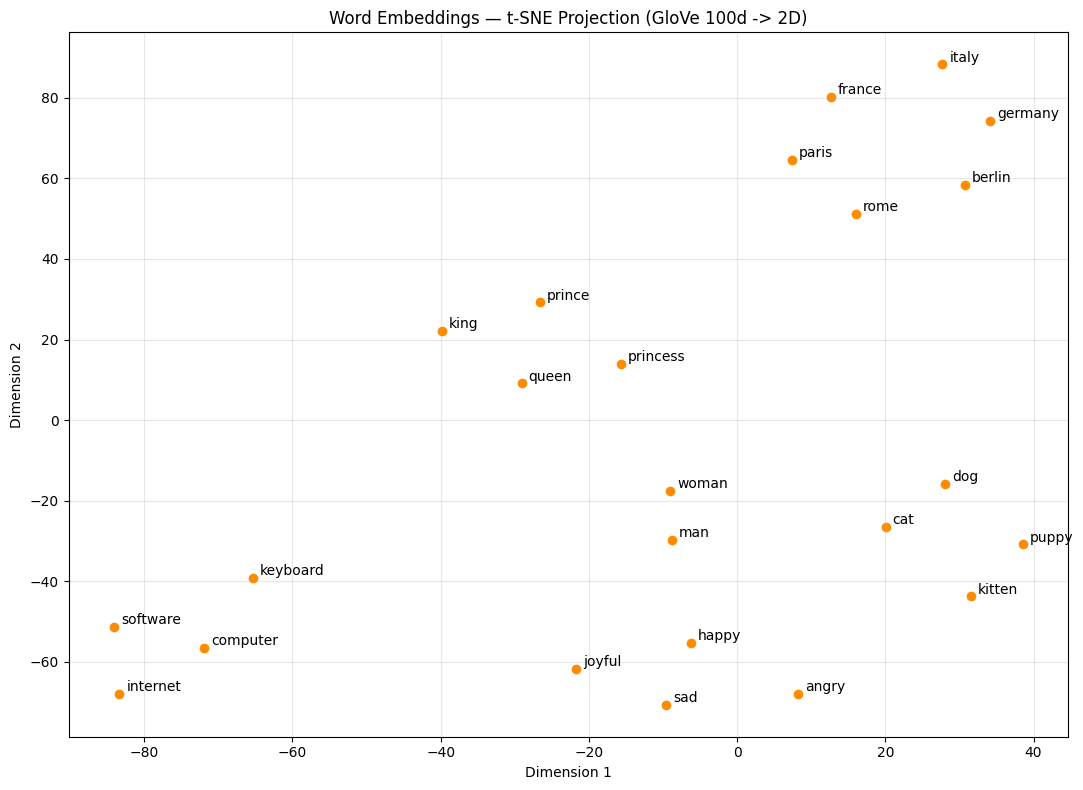

In [17]:
tsne = TSNE(n_components=2, random_state=42, perplexity=8, init="pca", learning_rate="auto")
vectors_tsne = tsne.fit_transform(vectors)

plt.figure(figsize=(11, 8))
plt.scatter(vectors_tsne[:, 0], vectors_tsne[:, 1], c="darkorange")
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (vectors_tsne[i, 0], vectors_tsne[i, 1]),
                 textcoords="offset points", xytext=(5, 2), fontsize=10)
plt.title("Word Embeddings — t-SNE Projection (GloVe 100d -> 2D)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Visualize - word2vec

Plotting 24 words, vector shape: (24, 300)


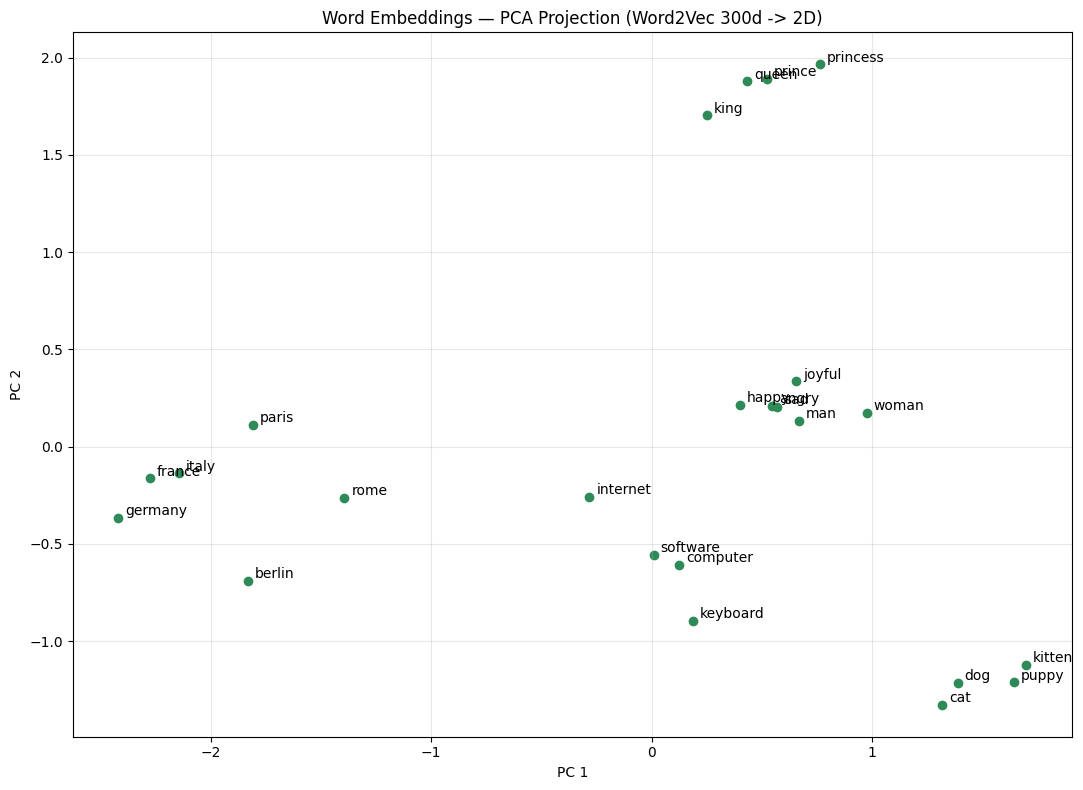

In [18]:
words_to_plot_w2v = [w for w in words_to_plot if w in word2vec_vectors]
vectors_w2v = np.array([word2vec_vectors[w] for w in words_to_plot_w2v])
print(f"Plotting {len(words_to_plot_w2v)} words, vector shape: {vectors_w2v.shape}")

pca_w2v = PCA(n_components=2, random_state=42)
vectors_w2v_pca = pca_w2v.fit_transform(vectors_w2v)

plt.figure(figsize=(11, 8))
plt.scatter(vectors_w2v_pca[:, 0], vectors_w2v_pca[:, 1], c="seagreen")
for i, word in enumerate(words_to_plot_w2v):
    plt.annotate(word, (vectors_w2v_pca[i, 0], vectors_w2v_pca[i, 1]),
                 textcoords="offset points", xytext=(5, 2), fontsize=10)
plt.title("Word Embeddings — PCA Projection (Word2Vec 300d -> 2D)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

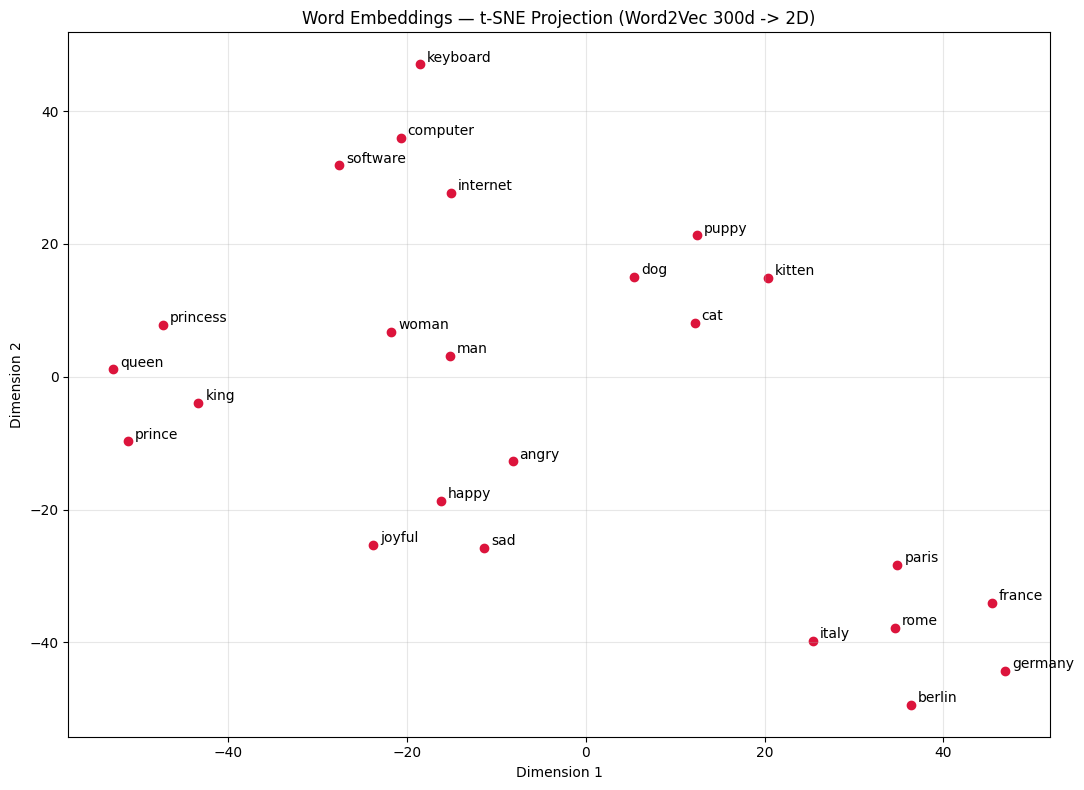

In [19]:
tsne_w2v = TSNE(n_components=2, random_state=42, perplexity=8, init="pca", learning_rate="auto")
vectors_w2v_tsne = tsne_w2v.fit_transform(vectors_w2v)

plt.figure(figsize=(11, 8))
plt.scatter(vectors_w2v_tsne[:, 0], vectors_w2v_tsne[:, 1], c="crimson")
for i, word in enumerate(words_to_plot_w2v):
    plt.annotate(word, (vectors_w2v_tsne[i, 0], vectors_w2v_tsne[i, 1]),
                 textcoords="offset points", xytext=(5, 2), fontsize=10)
plt.title("Word Embeddings — t-SNE Projection (Word2Vec 300d -> 2D)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# training model

In [20]:
corpus = [
    "I binge watched the entire show on Netflix last night. It was the most exciting show I have seen in years.".split(),
    "She streamed three movies on Netflix over the weekend. Netflix has a great collection of indie movies.".split(),
    "We finished an entire web series on Amazon Prime in two days. Amazon Prime has really improved its original series.".split(),
    "He prefers watching YouTube videos over Netflix shows. YouTube offers a wider variety of user-generated content.".split(),
    "Cricket and football are the most popular sports in India. Most Indian fans follow cricket matches religiously.".split(),
    "The football match went into a penalty shootout last night. It was a thrilling match for all the football fans.".split(),
    "India won the cricket match by a huge margin. The Indian cricket team played exceptionally well today.".split(),
    "Basketball is gaining popularity among college students. Many students spend their weekends playing basketball on campus.".split(),
    "I do not like waking up early for morning classes. Morning classes are often very difficult to attend regularly.".split(),
    "I really like staying up late to play video games. Playing video games is my favorite way to relax after a long day.".split(),
    "Most students skip breakfast before their first lecture. Skipping breakfast can lead to low energy during the lecture.".split(),
    "The college canteen gets crowded during lunch break. It is hard to find a seat in the canteen during the break.".split(),
    "I listen to Spotify playlists while studying for exams. Spotify helps me focus better during intense studying sessions.".split(),
    "She discovered a new artist through Instagram reels. Instagram reels are a great way to find trending music artists.".split(),
    "Concerts and music festivals are fun to attend with friends. Attending a music festival with friends is an unforgettable experience.".split()
]

In [21]:
print(f"Corpus has {len(corpus)} sentences.")

Corpus has 15 sentences.


In [22]:
cbow_model = Word2Vec(
    sentences=corpus,
    vector_size=50,   # embedding dimension
    window=3,          # context window size
    min_count=1,       # keep all words (toy corpus is tiny)
    sg=0,               # CBOW
    epochs=200,
    seed=42,
)

In [23]:
skipgram_model = Word2Vec(
    sentences=corpus,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,               # Skip-gram
    epochs=200,
    seed=42,
)

In [24]:
print("CBOW vocabulary size:", len(cbow_model.wv))
print("Skip-gram vocabulary size:", len(skipgram_model.wv))

CBOW vocabulary size: 186
Skip-gram vocabulary size: 186


In [25]:
# Inspect a vector
word = "Netflix"
print(f"CBOW vector for '{word}' (first 10 dims):\n", cbow_model.wv[word][:10])
print()
print(f"Skip-gram vector for '{word}' (first 10 dims):\n", skipgram_model.wv[word][:10])


CBOW vector for 'Netflix' (first 10 dims):
 [ 0.1005754  -0.26701456 -0.46623737  0.1561763   0.20273516  0.06623846
  0.00486591  0.53177184 -0.5712833   0.13581258]

Skip-gram vector for 'Netflix' (first 10 dims):
 [ 0.13115822 -0.24452022 -0.4459272   0.04553002  0.53653383 -0.07572314
 -0.03088166  0.04638569 -0.34048086 -0.03756183]


In [26]:
print("CBOW - most similar to 'Netflix':")
print(cbow_model.wv.most_similar("Netflix", topn=5))

print("\nSkip-gram - most similar to 'Netflix':")
print(skipgram_model.wv.most_similar("Netflix", topn=5))

CBOW - most similar to 'Netflix':
[('over', 0.9976184368133545), ('on', 0.9974989891052246), ('of', 0.9970378875732422), ('a', 0.9968809485435486), ('the', 0.9966934323310852)]

Skip-gram - most similar to 'Netflix':
[('weekend.', 0.972504198551178), ('over', 0.9689741730690002), ('movies', 0.9595168828964233), ('three', 0.9574528336524963), ('streamed', 0.9381418824195862)]


In [27]:
# mainly to understand mechanics of traning, ideally we need large corpus of data to get good vectors

# saving model

In [28]:
cbow_model.save("cbow_word2vec.model")
skipgram_model.save("skipgram_word2vec.model")
print("Models saved to disk.")

Models saved to disk.


# loading model

In [29]:
loaded_model = Word2Vec.load("cbow_word2vec.model")